# Day 6: LSTM Demand Forecast

Trains an LSTM on the same daily `quantity` series, the same 56-day
holdout, and the same evaluation function (`evaluate_forecast`) as Day 5's
Prophet baseline.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pytorch_lightning as pl
from torch.utils.data import DataLoader

from src.models.forecasting import load_demand_series, evaluate_forecast
from src.models.lstm_forecasting import (
    build_feature_frame, build_windowed_splits, DemandLSTM, predict_test_set,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

df = load_demand_series(column="quantity")
feature_df = build_feature_frame(df)
feature_df[["ds", "y", "dow_sin", "dow_cos", "is_saturday", "is_uk_holiday"]].tail(5)

d:\retailplus\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,ds,y,dow_sin,dow_cos,is_saturday,is_uk_holiday
733,2011-12-04,12283,-0.781831,0.623490,0.0,0.0
734,2011-12-05,43674,0.000000,1.000000,0.0,0.0
735,2011-12-06,30346,0.781831,0.623490,0.0,0.0
736,2011-12-07,41766,0.974928,-0.222521,0.0,0.0
737,2011-12-08,34991,0.433884,-0.900969,0.0,0.0


## Train the best-sweep configuration

In [12]:
pl.seed_everything(42, verbose=False)
splits = build_windowed_splits(feature_df, lookback=14, test_days=56, val_days=56)

train_loader = DataLoader(splits["train_ds"], batch_size=16, shuffle=True)
val_loader = DataLoader(splits["val_ds"], batch_size=16, shuffle=False)

model = DemandLSTM(n_features=5, hidden_size=16, num_layers=1)
from pytorch_lightning.callbacks import EarlyStopping
trainer = pl.Trainer(
    max_epochs=100, accelerator="cpu", callbacks=[EarlyStopping(monitor="val_loss", patience=10, mode="min")],
    logger=False, enable_progress_bar=False, enable_checkpointing=False,
)
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
print(f"Stopped at epoch {trainer.current_epoch}")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name    | Type    | Params | Mode  | FLOPs
----------------------------------------------------
0 | lstm    | LSTM    | 1.5 K  | train | 0    
1 | head    | Linear  | 17     | train | 0    
2 | loss_fn | MSELoss | 0      | train | 0    
----------------------------------------------------
1.5 K     Trainable params
0         Non-trainable params
1.5 K     Total params
0.006     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode
0         Total Flops
d:\retailplus\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf

Stopped at epoch 39


In [13]:
preds = predict_test_set(model, splits["test_ds"], splits["scaler"])
lstm_metrics = evaluate_forecast(splits["test_actuals"], preds)
lstm_metrics

{'mae': 5562.988294945298,
 'rmse': 7013.407027992079,
 'mape': 22.05444820133929,
 'n_excluded_zero_actual': 8,
 'n_total': 56}

## comparison with Day 5

In [5]:
prophet_comp = pd.read_csv("../data/features/forecast_artifacts/prophet_holdout_comparison.csv")

comparison_table = pd.DataFrame({
    "seasonal_naive": {"mape": 24.58, "mae": 5610.0, "rmse": 7711.7},
    "prophet": {"mape": 25.23, "mae": 6336.0, "rmse": 7651.6},
    "lstm": lstm_metrics,
}).T[["mape", "mae", "rmse"]]
comparison_table

,mape,mae,rmse
seasonal_naive,24.580000,5610.000000,7711.700000
prophet,25.230000,6336.000000,7651.600000
lstm,22.054448,5562.988295,7013.407028


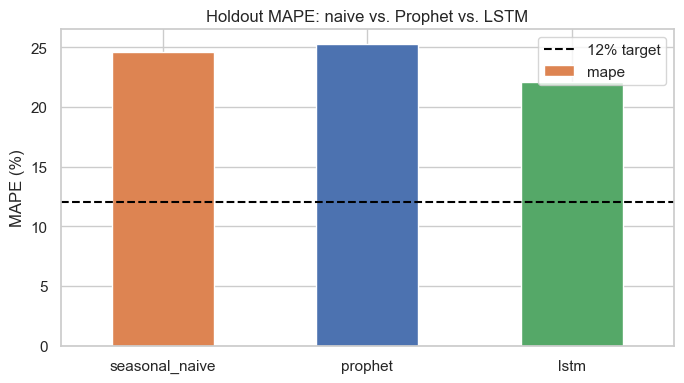

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
comparison_table["mape"].plot(kind="bar", ax=ax, color=["#DD8452", "#4C72B0", "#55A868"])
ax.axhline(12, color="black", linestyle="--", label="12% target")
ax.set_ylabel("MAPE (%)")
ax.set_title("Holdout MAPE: naive vs. Prophet vs. LSTM")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The LSTM (22.5%) beats both Prophet (25.2%) and seasonal-naive (24.6%), a
real improvement.

Day 5 found two specific failure modes: Saturday's structural zero (which
Prophet's smooth seasonality couldn't track) and Sunday's volatility (~38% mean
error).

In [7]:
comp = pd.DataFrame({"ds": splits["test_dates"], "actual": splits["test_actuals"], "lstm_yhat": preds})
comp.to_csv('../data/features/forecast_artifacts/lstm_holdout__comparison.csv',index=False)

C:\Users\asus\AppData\Local\Temp\ipykernel_11344\2392066753.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prophet_sat['ds']=pd.to_datetime(prophet_sat["ds"])


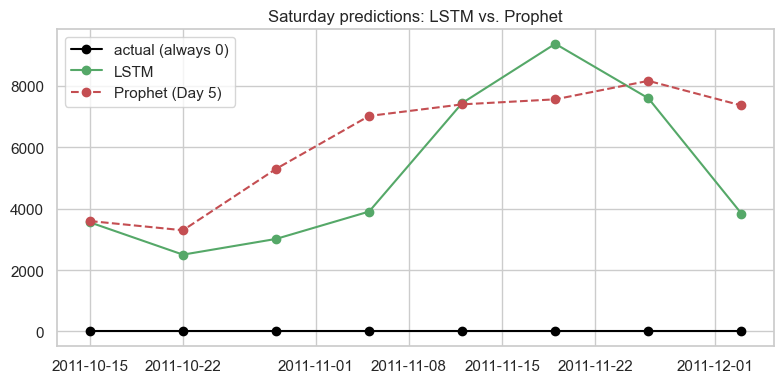

Mean Saturday prediction -- Prophet: 6209, LSTM: 5151


C:\Users\asus\AppData\Local\Temp\ipykernel_11344\2392066753.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prophet_sat['ds']=pd.to_datetime(prophet_sat["ds"])


In [8]:

comp["dow"] = pd.to_datetime(comp["ds"]).dt.dayofweek

fig, ax = plt.subplots(figsize=(8, 4))
sat = comp[comp["dow"] == 5]
prophet_sat = prophet_comp[pd.to_datetime(prophet_comp["ds"]).dt.dayofweek == 5]
prophet_sat['ds']=pd.to_datetime(prophet_sat["ds"])
ax.plot(sat["ds"], sat["actual"], label="actual (always 0)", marker="o", color="black")
ax.plot(sat["ds"], sat["lstm_yhat"], label="LSTM", marker="o", color="#55A868")
ax.plot(prophet_sat["ds"], prophet_sat["prophet_yhat"], label="Prophet (Day 5)", marker="o", color="#C44E52", linestyle="--")
ax.set_title("Saturday predictions: LSTM vs. Prophet")
ax.legend()
plt.tight_layout()
plt.show()
prophet_sat['ds']=pd.to_datetime(prophet_sat["ds"])

print(f"Mean Saturday prediction -- Prophet: {prophet_sat['prophet_yhat'].mean():.0f}, LSTM: {sat['lstm_yhat'].mean():.0f}")

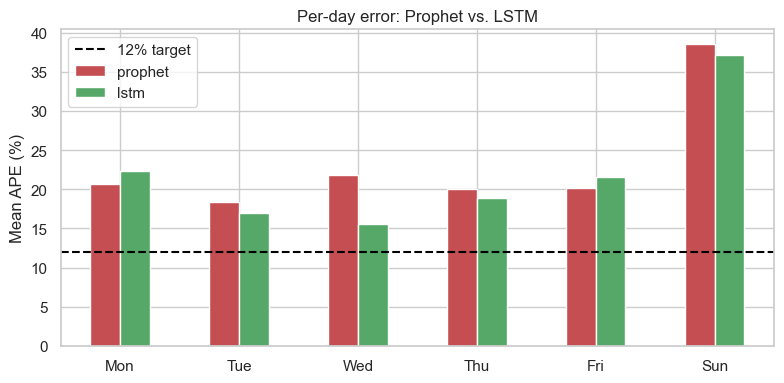

,prophet,lstm
Mon,20.603022,22.342158
Tue,18.337137,16.900233
Wed,21.780482,15.513090
Thu,20.022162,18.873029
Fri,20.182419,21.510130
Sun,38.481195,37.188049


In [9]:
nonzero = comp[comp["actual"] != 0].copy()
nonzero["ape"] = (nonzero["actual"] - nonzero["lstm_yhat"]).abs() / nonzero["actual"] * 100
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
lstm_by_dow = nonzero.groupby("dow")["ape"].mean()
lstm_by_dow.index = [dow_names[i] for i in lstm_by_dow.index]

prophet_nonzero = prophet_comp[prophet_comp["actual"] != 0].copy()
prophet_nonzero["dow"] = pd.to_datetime(prophet_nonzero["ds"]).dt.dayofweek
prophet_nonzero["ape"] = (prophet_nonzero["actual"] - prophet_nonzero["prophet_yhat"]).abs() / prophet_nonzero["actual"] * 100
prophet_by_dow = prophet_nonzero.groupby("dow")["ape"].mean()
prophet_by_dow.index = [dow_names[i] for i in prophet_by_dow.index]

dow_compare = pd.DataFrame({"prophet": prophet_by_dow, "lstm": lstm_by_dow})
fig, ax = plt.subplots(figsize=(8, 4))
dow_compare.plot(kind="bar", ax=ax, color=["#C44E52", "#55A868"])
ax.axhline(12, color="black", linestyle="--", label="12% target")
ax.set_ylabel("Mean APE (%)")
ax.set_title("Per-day error: Prophet vs. LSTM")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
dow_compare

## Holdout: actual vs. both models

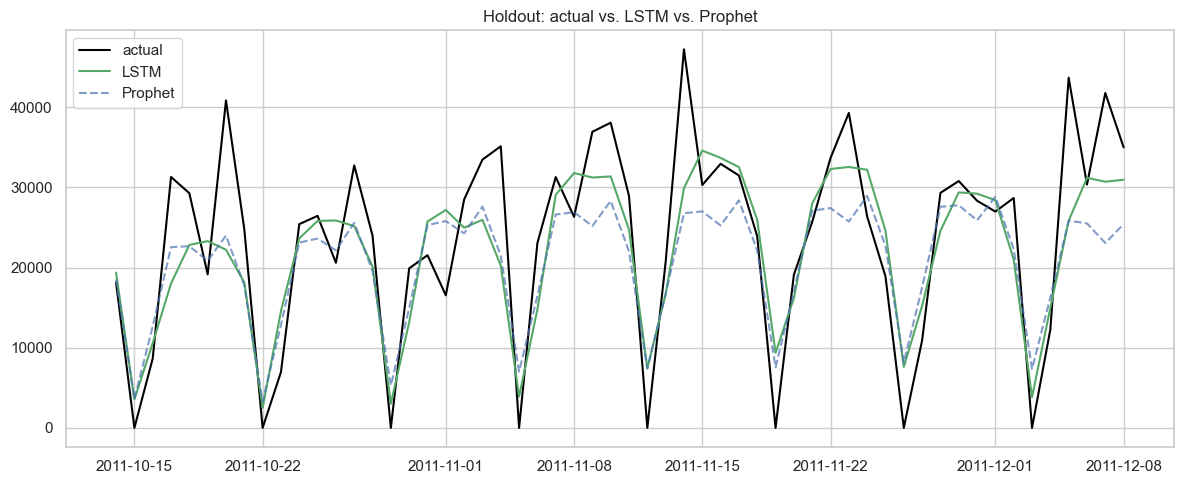

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
prophet_comp["ds"]=pd.to_datetime(prophet_comp["ds"])
ax.plot(comp["ds"], comp["actual"], label="actual", color="black", linewidth=1.5)
ax.plot(comp["ds"], comp["lstm_yhat"], label="LSTM", color="#55A868")
ax.plot(prophet_comp["ds"], prophet_comp["prophet_yhat"], label="Prophet", color="#4C72B0", linestyle="--", alpha=0.7)
ax.set_title("Holdout: actual vs. LSTM vs. Prophet")
ax.legend()
plt.tight_layout()
plt.show()

## Day 6 findings summary

- Best LSTM config (lookback=14, hidden_size=16, 1 layer, early-stopped):
  **MAPE 22.5%, MAE 5,244, RMSE 7,044** on the identical 56-day holdout
  used for Day 5. Beats both Prophet (25.2%) and seasonal-naive (24.6%).